In [1]:
import datasets
import torch
import torch.nn as nn
import torch.nn.functional as f
import numpy as np
from torch.utils.data import Dataset, DataLoader
import math


In [2]:

# Load the full dataset (all splits)
ds = datasets.load_dataset('tiny_shakespeare', trust_remote_code=True)

# Access individual splits
train_data = ds['train']
val_data = ds['validation']
test_data = ds['test']

# Print a sample from the train split
print(train_data[0]['text'][:500])  # First 500 characters of the text

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


# Tokenizer

In [3]:

class CharTokenizer:
    def __init__(self, corpus):
        self.tokens = self.tokenize(corpus)
        self.vocabulary = ['<UNK>', '<PAD>'] + sorted(list(set(self.tokens)))
        self.vocab_size = len(self.vocabulary)
        self.stoi = {ch:i for i, ch in enumerate(self.vocabulary)}
        self.itos = {i:ch for i, ch in enumerate(self.vocabulary)}

    def str_2_int(self, text):
        return torch.tensor([self.stoi.get(ch, self.stoi['<UNK>']) for ch in text], dtype=torch.long)

    def int_2_str(self, encoded):
        encoded_list = encoded.numpy()  # Fast conversion
        return [self.itos.get(i, self.stoi['<UNK>']) for i in encoded_list]
    
    def get_data(self):
        return self.vocabulary, self.vocab_size
    
    def tokenize(self, corpus):
        return list(str(corpus['text'][0]).lower())


tokenizer = CharTokenizer(train_data)
vocabulary, vocab_size = tokenizer.get_data()

train_tokens = tokenizer.tokenize(train_data)
data_train = tokenizer.str_2_int(train_tokens)

val_tokens = tokenizer.tokenize(val_data)
data_val = tokenizer.str_2_int(val_tokens)

test_tokens = tokenizer.tokenize(test_data)
data_test = tokenizer.str_2_int(test_tokens)



# tokenizer.int_2_str(data_train)
vocab_size

41

In [4]:
x = [1, 2, 3, 4, 5, 6, 7, 8 , 9]

len(x)-4

5

# Data Pipeline

In [5]:

class GPT_DataSet(Dataset):
    def __init__(self, corpus, block_size):
        self.corpus = corpus
        self.block_size = block_size
    
    def __len__(self):
        return len(self.corpus) - self.block_size

    def __getitem__(self, i):
        return self.corpus[i:i+self.block_size], self.corpus[i+1:i+1+self.block_size]


block_size = 4
batch_size = 32
train_dataset = GPT_DataSet(data_train, block_size)
val_dataset = GPT_DataSet(data_val, block_size)
test_dataset = GPT_DataSet(data_test, block_size)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# train_loader[0], val_loader[0], test_loader[0]

# GPT Implementation

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class Simple_GPT(nn.Module):
    def __init__(self, vocab_size, embed_dim, block_size, num_heads, layers):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_size = embed_dim // num_heads
        self.embed_dim = embed_dim
        self.layers = layers
        self.block_size = block_size

        # Embeddings
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.register_buffer('pos_embeddings', self.pos_encoding(embed_dim, block_size))

        # Attention projections (shared across layers for simplicity;
        # use ModuleList below if you want per-layer projections)
        self.q_proj = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for _ in range(layers)])
        self.k_proj = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for _ in range(layers)])
        self.v_proj = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for _ in range(layers)])
        self.out_proj = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for _ in range(layers)])

        # Per-layer LayerNorms
        self.ln1 = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in range(layers)])
        self.ln2 = nn.ModuleList([nn.LayerNorm(embed_dim) for _ in range(layers)])

        # Per-layer Feed-forward (4x expansion with GELU, as in GPT-2)
        self.ff = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embed_dim, 4 * embed_dim),
                nn.GELU(),
                nn.Linear(4 * embed_dim, embed_dim)
            )
            for _ in range(layers)
        ])

        # Final LayerNorm before LM head (GPT-2 style)
        self.final_ln = nn.LayerNorm(embed_dim)

        # LM head
        self.output_linear = nn.Linear(embed_dim, vocab_size)

    # ------------------------------------------------------------------ #
    #  Positional encoding                                                 #
    # ------------------------------------------------------------------ #
    def pos_encoding(self, embed_dims, block_size):
        pe = torch.zeros(block_size, embed_dims)
        for pos in range(block_size):
            for i in range(0, embed_dims, 2):
                angle = pos / (10000 ** (i / embed_dims))
                pe[pos, i]     = math.sin(angle)
                if i + 1 < embed_dims:
                    pe[pos, i + 1] = math.cos(angle)
        return pe.unsqueeze(0)          # (1, block_size, embed_dims)

    # ------------------------------------------------------------------ #
    #  Multi-head self-attention (no separate Head class)                 #
    # ------------------------------------------------------------------ #
    def multi_head_attention(self, x, layer_idx, use_mask=True):
        B, T, C = x.shape                       # batch, seq_len, embed_dim

        # Project and reshape to (B, num_heads, T, head_size)
        q = self.q_proj[layer_idx](x).view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        k = self.k_proj[layer_idx](x).view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        v = self.v_proj[layer_idx](x).view(B, T, self.num_heads, self.head_size).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_size)  # (B, H, T, T)

        if use_mask:
            mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
            scores = scores.masked_fill(mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)                    # (B, H, T, T)
        attn_output  = torch.matmul(attn_weights, v)                # (B, H, T, head_size)

        # Merge heads back: (B, T, embed_dim)
        attn_output = attn_output.transpose(1, 2).contiguous().view(B, T, C)

        return self.out_proj[layer_idx](attn_output)

    # ------------------------------------------------------------------ #
    #  Feed-forward                                                        #
    # ------------------------------------------------------------------ #
    def feed_forward(self, x, layer_idx):
        return self.ff[layer_idx](x)

    # ------------------------------------------------------------------ #
    #  Single decoder block  (Pre-LN — GPT-2 / "simple transformers")    #
    # ------------------------------------------------------------------ #
    def decoder(self, x, layer_idx):
        # Pre-LN attention sub-layer
        x = x + self.multi_head_attention(self.ln1[layer_idx](x), layer_idx)
        # Pre-LN feed-forward sub-layer
        x = x + self.feed_forward(self.ln2[layer_idx](x), layer_idx)
        return x

    # ------------------------------------------------------------------ #
    #  Forward pass                                                        #
    # ------------------------------------------------------------------ #
    def forward(self, idx):
        B, T = idx.shape
        assert T <= self.block_size, f"Sequence length {T} exceeds block_size {self.block_size}"

        # Token + positional embeddings
        x = self.token_embeddings(idx) + self.pos_embeddings[:, :T, :]   # (B, T, C)

        # Stack of decoder blocks
        for i in range(self.layers):
            x = self.decoder(x, i)

        # Final LayerNorm + LM head
        x = self.final_ln(x)
        logits = self.output_linear(x)   # (B, T, vocab_size)
        return logits


# ------------------------------------------------------------------ #
#  Example instantiation                                              #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    vocab_size = 50257
    embed_dim  = 128
    block_size = 128
    num_heads  = 4
    layers     = 6

    model = Simple_GPT(vocab_size, embed_dim, block_size, num_heads, layers)
    # print(model)

    # Quick forward pass sanity check
    dummy_input = torch.randint(0, vocab_size, (2, 16))  # batch=2, seq_len=16
    logits = model(dummy_input)
    print("Output shape:", logits.shape)   # Expected: (2, 16, 50257)

Output shape: torch.Size([2, 16, 50257])


# Training Loop

In [16]:
import torch.optim as optim
from tqdm import tqdm

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Move model to device
model = Simple_GPT(vocab_size, embed_dim, block_size, num_heads, layers).to(device)

# 2. Hyperparameters
epochs = 5
learning_rate = 3e-4  # Standard starting LR for Transformers
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# 3. Loggin
history = {'train_loss':[], 'val_loss': []}


Training on: cuda


In [22]:

best_val_loss = float('inf')

# 3. Training Loop
for epoch in range(epochs):
    model.train()  # Set model to training mode
    total_train_loss = 0
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), leave=True, desc=f'Epoch {epoch+1}')
    for batch_idx, (xb, yb) in pbar:
        # Move data to the same device as the model
        xb, yb = xb.to(device), yb.to(device)
        
        # Forward pass
        logits = model(xb)  # Shape: (B, T, vocab_size)
        
        # CrossEntropyLoss expects inputs as (N, C) and targets as (N)
        # So we flatten the Batch and Time dimensions
        B, T, C = logits.shape
        logits_flat = logits.view(B * T, C)
        yb_flat = yb.view(B * T)
        
        # Calculate loss
        loss = criterion(logits_flat, yb_flat)
        
        # Backward pass & Optimizer step
        optimizer.zero_grad(set_to_none=True)  # Slightly faster than standard zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
            
    # Calculate average training loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    
    # 4. Validation Loop
    model.eval()  # Set model to evaluation mode
    total_val_loss = 0
    
    with torch.no_grad():  # Disable gradient tracking for validation
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            logits = model(xb)
            logits_flat = logits.view(-1, C)
            yb_flat = yb.view(-1)
            
            val_loss = criterion(logits_flat, yb_flat)
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)

    # Inside the training loop, after calculating avg_val_loss:
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"New best model saved with val loss: {best_val_loss:.4f}")
    
    print(f"=== Epoch {epoch+1}/{epochs} Complete | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} ===")
    
    # 5. Logging
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)


Epoch 1: 100%|██████████| 31371/31371 [06:42<00:00, 77.99it/s, loss=1.7986]


=== Epoch 1/5 Complete | Train Loss: 1.9155 | Val Loss: 1.9679 ===


Epoch 2: 100%|██████████| 31371/31371 [06:26<00:00, 81.20it/s, loss=1.8862]


=== Epoch 2/5 Complete | Train Loss: 1.8916 | Val Loss: 1.9550 ===


Epoch 3: 100%|██████████| 31371/31371 [06:24<00:00, 81.66it/s, loss=2.0783]


=== Epoch 3/5 Complete | Train Loss: 1.8801 | Val Loss: 1.9545 ===


Epoch 4:   0%|          | 124/31371 [00:01<06:17, 82.88it/s, loss=1.8825]


KeyboardInterrupt: 


>>> 1. Training Curves


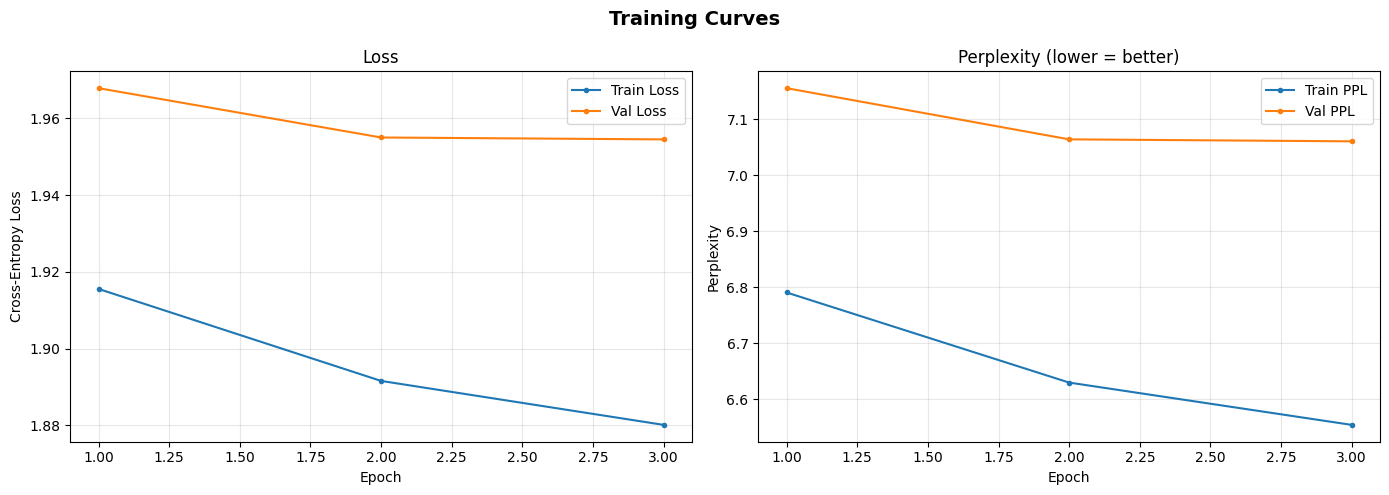

Best Val Loss : 1.9545  (epoch 3)
Best Val PPL  : 7.06
Generalisation Gap (final): +0.0744

>>> 2. Summary Statistics

  MODEL SUMMARY
  Total parameters     : 14,105,937
  Trainable parameters : 14,105,937
  Layers               : 6
  Heads                : 4
  Embed dim            : 128
  Head size            : 32

  TRAINING SUMMARY
  Epochs trained       : 3
  Final train loss     : 1.8801
  Final val   loss     : 1.9545
  Best val    loss     : 1.9545  (epoch 3)
  Best val    PPL      : 7.06
  Generalisation gap   : +0.0744


>>> 3. Token Accuracy
Top-1 Accuracy: 39.59%
Top-5 Accuracy: 76.75%

>>> 4. Per-Position Loss


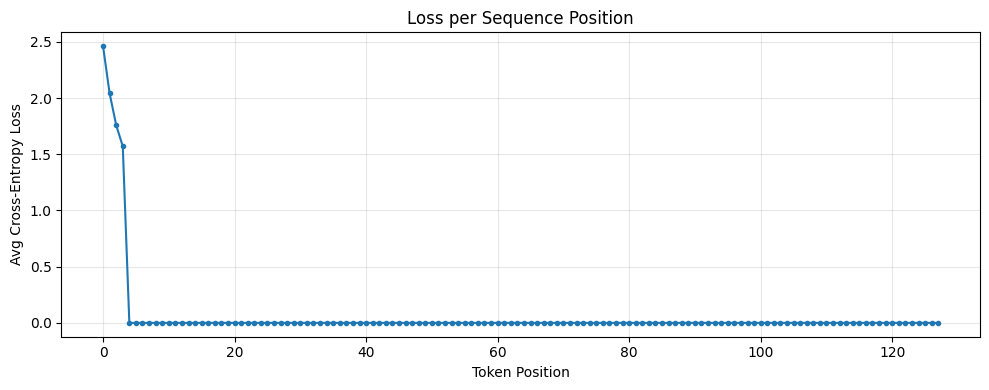


>>> 5. Attention Entropy


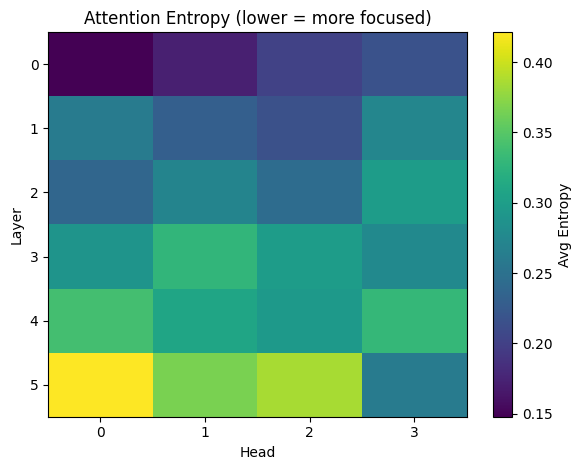


>>> 6. Qualitative Generation

  QUALITATIVE GENERATION ANALYSIS

📝 Prompt: "Once upon a time"
-----------------------------------------------------------------
  [temp=0.5] Once upon a timetime thonthontisthesthestwarelely t t gelely thonthely meles arithonat t t thelelelely nghongly:
pthout t t t t t sithounanunesithousthousthongearousthong
  [temp=1.0] Once upon a timetime? brelumouseshesticisinat ghonittweest blinices:
trarivadeslighent misongly:
athes be mit bly, milonsthelesponghoningewhouongrkstusistule,

thudelidri
  [temp=1.5] Once upon a timetime nthaarouphedovonvicharstin inifime-morrouled
kse
rifustt lu;
pese knadu,

wely waray ithelly, tin:
omiousheosut!riny: iche.

waustchesy,me. onesh;
at


📝 Prompt: "The model learned to"
-----------------------------------------------------------------
  [temp=0.5] The model learned tod touthonenearkinearichinarichitistichimbre ousthelit te he minthithithaladingly:

t thousthe y,
stititithoustengly:
the.
thely,


arionellely:


itesth

In [25]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
import math

# ============================================================
#  PART 1 — QUANTITATIVE ANALYSIS
# ============================================================

# ── 1.1  Training Curves ────────────────────────────────────
def plot_training_curves(history):
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    epochs     = range(1, len(train_loss) + 1)

    train_ppl = [math.exp(l) for l in train_loss]
    val_ppl   = [math.exp(l) for l in val_loss]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training Curves', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(epochs, train_loss, label='Train Loss', marker='o', markersize=3)
    axes[0].plot(epochs, val_loss,   label='Val Loss',   marker='o', markersize=3)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Perplexity
    axes[1].plot(epochs, train_ppl, label='Train PPL', marker='o', markersize=3)
    axes[1].plot(epochs, val_ppl,   label='Val PPL',   marker='o', markersize=3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Perplexity (lower = better)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print(f"Best Val Loss : {min(val_loss):.4f}  (epoch {val_loss.index(min(val_loss))+1})")
    print(f"Best Val PPL  : {min(val_ppl):.2f}")
    print(f"Generalisation Gap (final): {val_loss[-1] - train_loss[-1]:+.4f}")


# ── 1.2  Per-Token Accuracy & Top-k Accuracy ────────────────
def compute_accuracy(model, loader, device, top_k=(1, 5)):
    model.eval()
    correct = defaultdict(int)
    total   = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)                        # (B, T, vocab_size)
            B, T, V = logits.shape
            logits_flat = logits.view(B * T, V)
            yb_flat     = yb.view(B * T)

            for k in top_k:
                _, pred = logits_flat.topk(k, dim=-1)  # (B*T, k)
                correct[k] += pred.eq(yb_flat.unsqueeze(1)).any(dim=1).sum().item()

            total += yb_flat.size(0)

    for k in top_k:
        print(f"Top-{k} Accuracy: {100 * correct[k] / total:.2f}%")
    return {k: correct[k] / total for k in top_k}


# ── 1.3  Per-Position Loss (how hard is each position?) ─────
def per_position_loss(model, loader, device, block_size):
    model.eval()
    pos_loss  = torch.zeros(block_size, device=device)
    pos_count = torch.zeros(block_size, device=device)

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)                         # (B, T, V)
            B, T, V = logits.shape

            for t in range(T):
                loss_t = F.cross_entropy(logits[:, t, :], yb[:, t], reduction='sum')
                pos_loss[t]  += loss_t
                pos_count[t] += B

    pos_loss = (pos_loss / pos_count.clamp(min=1)).cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(pos_loss, marker='o', markersize=3)
    plt.xlabel('Token Position'); plt.ylabel('Avg Cross-Entropy Loss')
    plt.title('Loss per Sequence Position')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('per_position_loss.png', dpi=150)
    plt.show()
    return pos_loss


# ── 1.4  Attention Entropy (how focused are heads?) ─────────
def attention_entropy(model, loader, device, num_samples=50):
    """
    Hooks into all out_proj layers to capture attention weights.
    Lower entropy  → head is more focused (sharper attention).
    Higher entropy → head attends broadly.
    """
    model.eval()
    entropy_per_layer_head = defaultdict(list)   # {(layer, head): [entropy values]}

    # We need raw softmax weights; register a forward hook on each ln1
    # Simpler: re-run the attention manually for a small batch
    sample_count = 0
    with torch.no_grad():
        for xb, _ in loader:
            if sample_count >= num_samples:
                break
            xb = xb.to(device)
            B, T = xb.shape

            x = model.token_embeddings(xb) + model.pos_embeddings[:, :T, :]

            for layer_idx in range(model.layers):
                normed = model.ln1[layer_idx](x)
                q = model.q_proj[layer_idx](normed).view(B, T, model.num_heads, model.head_size).transpose(1, 2)
                k = model.k_proj[layer_idx](normed).view(B, T, model.num_heads, model.head_size).transpose(1, 2)

                scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(model.head_size)
                mask   = torch.triu(torch.ones(T, T, device=device), diagonal=1).bool()
                scores = scores.masked_fill(mask, float('-inf'))
                attn   = F.softmax(scores, dim=-1)   # (B, H, T, T)

                # Entropy per head: -sum(p log p) over the key dimension
                attn_safe = attn.clamp(min=1e-9)
                ent = -(attn_safe * attn_safe.log()).sum(dim=-1)   # (B, H, T)
                ent = ent.mean(dim=(0, 2))                         # (H,)

                for h in range(model.num_heads):
                    entropy_per_layer_head[(layer_idx, h)].append(ent[h].item())

                # Step x forward through this layer
                x = model.decoder(x, layer_idx)

            sample_count += B

    # Plot heatmap: rows=layers, cols=heads
    L, H = model.layers, model.num_heads
    grid = np.zeros((L, H))
    for (l, h), vals in entropy_per_layer_head.items():
        grid[l, h] = np.mean(vals)

    fig, ax = plt.subplots(figsize=(max(6, H * 1.2), max(4, L * 0.8)))
    im = ax.imshow(grid, aspect='auto', cmap='viridis')
    ax.set_xlabel('Head'); ax.set_ylabel('Layer')
    ax.set_title('Attention Entropy (lower = more focused)')
    ax.set_xticks(range(H)); ax.set_yticks(range(L))
    plt.colorbar(im, ax=ax, label='Avg Entropy')
    plt.tight_layout()
    plt.savefig('attention_entropy.png', dpi=150)
    plt.show()
    return grid


# ── 1.5  Gradient Flow ───────────────────────────────────────
def plot_gradient_flow(model):
    """
    Call AFTER loss.backward() but BEFORE optimizer.step().
    Shows mean absolute gradient per named parameter layer.
    """
    means, maxes, names = [], [], []
    for name, param in model.named_parameters():
        if param.grad is not None and param.requires_grad:
            grad = param.grad.abs()
            means.append(grad.mean().item())
            maxes.append(grad.max().item())
            names.append(name)

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.4), 5))
    ax.bar(range(len(means)), means, alpha=0.7, label='Mean |grad|')
    ax.bar(range(len(maxes)), maxes, alpha=0.4, label='Max |grad|')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_ylabel('Gradient Magnitude')
    ax.set_title('Gradient Flow Across Parameters')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gradient_flow.png', dpi=150)
    plt.show()


# ── 1.6  Summary Statistics ──────────────────────────────────
def print_summary(model, history, val_loader, device, criterion):
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print("\n" + "="*55)
    print("  MODEL SUMMARY")
    print("="*55)
    print(f"  Total parameters     : {total_params:,}")
    print(f"  Trainable parameters : {trainable_params:,}")
    print(f"  Layers               : {model.layers}")
    print(f"  Heads                : {model.num_heads}")
    print(f"  Embed dim            : {model.embed_dim}")
    print(f"  Head size            : {model.head_size}")

    print("\n" + "="*55)
    print("  TRAINING SUMMARY")
    print("="*55)
    best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
    print(f"  Epochs trained       : {len(history['train_loss'])}")
    print(f"  Final train loss     : {history['train_loss'][-1]:.4f}")
    print(f"  Final val   loss     : {history['val_loss'][-1]:.4f}")
    print(f"  Best val    loss     : {min(history['val_loss']):.4f}  (epoch {best_epoch})")
    print(f"  Best val    PPL      : {math.exp(min(history['val_loss'])):.2f}")
    print(f"  Generalisation gap   : {history['val_loss'][-1] - history['train_loss'][-1]:+.4f}")
    print("="*55 + "\n")


# ============================================================
#  PART 2 — QUALITATIVE ANALYSIS  (text generation)
# ============================================================

def generate(model, encode, decode, prompt, device,
             max_new_tokens=200, temperature=1.0, top_k=40):
    """
    Autoregressively generate text from a prompt string.

    Args:
        encode  : callable str  → List[int]   (your tokeniser)
        decode  : callable List[int] → str
        temperature : >1 = more random, <1 = sharper
        top_k   : sample from top-k logits only (0 = disabled)
    """
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -model.block_size:]        # trim to block_size
            logits   = model(idx_cond)                   # (1, T, vocab_size)
            logits   = logits[:, -1, :] / temperature    # last token only

            if top_k > 0:
                values, _ = torch.topk(logits, top_k)
                logits[logits < values[:, -1:]] = float('-inf')

            probs    = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat([idx, next_tok], dim=1)

    return decode(idx[0].tolist())


def qualitative_analysis(model, encode, decode, device, prompts=None,
                          temperatures=(0.5, 1.0, 1.5), max_new_tokens=150):
    """
    Run generation for multiple prompts and temperatures,
    then print a clean side-by-side comparison.
    """
    if prompts is None:
        prompts = ["Once upon a time", "The model learned to", "In the beginning"]

    print("\n" + "="*65)
    print("  QUALITATIVE GENERATION ANALYSIS")
    print("="*65)

    for prompt in prompts:
        print(f"\n📝 Prompt: \"{prompt}\"")
        print("-" * 65)
        for temp in temperatures:
            output = generate(model, encode, decode, prompt, device,
                              max_new_tokens=max_new_tokens, temperature=temp)
            # strip prompt from output for display
            generated = output[len(prompt):]
            print(f"  [temp={temp}] {prompt}\033[92m{generated}\033[0m")
        print()


# ============================================================
#  ENTRY POINT — run everything
# ============================================================

def run_full_analysis(model, history, train_loader, val_loader,
                      device, criterion, encode, decode,
                      block_size, qualitative_prompts=None):
    """
    Call this after training completes.

    Example:
        run_full_analysis(
            model, history, train_loader, val_loader,
            device, criterion,
            encode=tokenizer.encode,
            decode=tokenizer.decode,
            block_size=block_size,
        )
    """
    print("\n>>> 1. Training Curves")
    plot_training_curves(history)

    print("\n>>> 2. Summary Statistics")
    print_summary(model, history, val_loader, device, criterion)

    print("\n>>> 3. Token Accuracy")
    compute_accuracy(model, val_loader, device, top_k=(1, 5))

    print("\n>>> 4. Per-Position Loss")
    per_position_loss(model, val_loader, device, block_size)

    print("\n>>> 5. Attention Entropy")
    attention_entropy(model, val_loader, device)

    print("\n>>> 6. Qualitative Generation")
    qualitative_analysis(model, encode, decode, device, prompts=qualitative_prompts)

# Define encode/decode functions for the analysis
encode = lambda text: tokenizer.str_2_int(text).tolist()
decode = lambda tokens: ''.join(tokenizer.int_2_str(torch.tensor(tokens)))

run_full_analysis(
    model        = model,
    history      = history,          # your existing history dict
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    criterion    = criterion,
    encode       = encode,           # str → List[int]
    decode       = decode,           # List[int] → str
    block_size   = block_size,
    qualitative_prompts = [
        "Once upon a time",
        "The model learned to",
        "In the beginning"
    ]
)